In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import os
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
import time
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

In [3]:
# Check GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("="*70)
print("SYSTEM INFORMATION")
print("="*70)
print(f"PyTorch Version: {torch.__version__}")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    print(f"CUDA Version: {torch.version.cuda}")
else:
    print("WARNING: No GPU detected! Training will be slow.")
print("="*70)

SYSTEM INFORMATION
PyTorch Version: 2.5.1
Device: cuda
GPU: NVIDIA GeForce GTX 1650
GPU Memory: 4.29 GB
CUDA Version: 12.1


In [4]:
class SpatialChannelAttention(nn.Module):
    """
    Novel Component 1: Spatial-Channel Tumor Attention (SCTA)
    Combines spatial and channel attention for tumor-specific feature enhancement
    """
    def __init__(self, channels, reduction=16):
        super().__init__()
        
        # Channel Attention
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        
        self.fc = nn.Sequential(
            nn.Conv2d(channels, channels // reduction, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels // reduction, channels, 1, bias=False)
        )
        
        # Spatial Attention
        self.spatial_conv = nn.Sequential(
            nn.Conv2d(2, 1, kernel_size=7, padding=3, bias=False),
            nn.BatchNorm2d(1)
        )
        
    def forward(self, x):
        # Channel attention
        avg_out = self.fc(self.avg_pool(x))
        max_out = self.fc(self.max_pool(x))
        channel_attn = torch.sigmoid(avg_out + max_out)
        x = x * channel_attn
        
        # Spatial attention
        avg_spatial = torch.mean(x, dim=1, keepdim=True)
        max_spatial, _ = torch.max(x, dim=1, keepdim=True)
        spatial_concat = torch.cat([avg_spatial, max_spatial], dim=1)
        spatial_attn = torch.sigmoid(self.spatial_conv(spatial_concat))
        x = x * spatial_attn
        
        return x


class AsymmetricPyramidFusion(nn.Module):
    """
    Novel Component 2: Asymmetric Pyramid Fusion (APF)
    Efficient multi-scale feature integration with learnable weights
    """
    def __init__(self, low_channels, high_channels, out_channels):
        super().__init__()
        
        self.low_reduce = nn.Sequential(
            nn.Conv2d(low_channels, out_channels // 2, 1, bias=False),
            nn.BatchNorm2d(out_channels // 2),
            nn.ReLU(inplace=True)
        )
        
        self.high_reduce = nn.Sequential(
            nn.Conv2d(high_channels, out_channels // 2, 1, bias=False),
            nn.BatchNorm2d(out_channels // 2),
            nn.ReLU(inplace=True)
        )
        
        self.refine = nn.Sequential(
            nn.Conv2d(out_channels, out_channels, 3, padding=1, groups=out_channels, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.1)
        )
        
    def forward(self, low_feat, high_feat):
        target_size = (low_feat.size(2), low_feat.size(3))
        high_up = F.interpolate(high_feat, size=target_size, 
                               mode='bilinear', align_corners=True)
        
        low = self.low_reduce(low_feat)
        high = self.high_reduce(high_up)
        
        fused = torch.cat([low, high], dim=1)
        out = self.refine(fused)
        
        return out


class ProgressiveFeatureRefinement(nn.Module):
    """
    Novel Component 3: Progressive Feature Refinement (PFR)
    Hierarchical enhancement with multi-receptive field processing
    """
    def __init__(self, channels):
        super().__init__()
        
        # Stage 1
        self.dw_conv1 = nn.Conv2d(channels, channels, 3, padding=1, 
                                 groups=channels, bias=False)
        self.bn1 = nn.BatchNorm2d(channels)
        self.pw_conv1 = nn.Conv2d(channels, channels, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(channels)
        
        # Stage 2 with dilation
        self.dw_conv2 = nn.Conv2d(channels, channels, 3, padding=2, 
                                 dilation=2, groups=channels, bias=False)
        self.bn3 = nn.BatchNorm2d(channels)
        self.pw_conv2 = nn.Conv2d(channels, channels, 1, bias=False)
        self.bn4 = nn.BatchNorm2d(channels)
        
        self.relu = nn.ReLU(inplace=True)
        
    def forward(self, x):

        identity = x
        
        # Stage 1
        out = self.dw_conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.pw_conv1(out)
        out = self.bn2(out)
        out = self.relu(out + identity)
        
        # Stage 2
        identity2 = out
        out = self.dw_conv2(out)
        out = self.bn3(out)
        out = self.relu(out)
        out = self.pw_conv2(out)
        out = self.bn4(out)
        out = self.relu(out + identity2)
        
        return out

print("✓ Novel components defined successfully")



✓ Novel components defined successfully


In [5]:

from torchvision.models.feature_extraction import create_feature_extractor

class TumorNetLite(nn.Module):
    """
    TumorNet-Lite: Complete architecture with 4 novel components
    Lightweight brain tumor classification model for IEEE publication
    """
    def __init__(self, num_classes=4, pretrained=True):
        super().__init__()
        
        # Backbone: MobileNetV2
        backbone = models.mobilenet_v2(pretrained=pretrained)
        return_nodes = {
            'features.3': 'low_feat',    # 50x50x24
            'features.13': 'high_feat',  # 13x13x96
            'features.18': 'final_feat'  # 7x7x1280
        }
        self.features = create_feature_extractor(backbone, return_nodes=return_nodes)
        
        # Novel Component 1: SCTA at multiple scales
        self.scta_low = SpatialChannelAttention(24, reduction=16)
        self.scta_high = SpatialChannelAttention(96, reduction=16)
        
        # Novel Component 2: APF
        self.apf = AsymmetricPyramidFusion(24, 96, 256)
        
        # Novel Component 3: PFR
        self.pfr = ProgressiveFeatureRefinement(256)
        
        # Global pooling
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.refined_pool = nn.AdaptiveAvgPool2d(1)
        
        # Novel Component 4: Uncertainty-Aware Classifier
        combined_features = 256 + 1280  # refined + global
        
        self.classifier = nn.Sequential(
            nn.Linear(combined_features, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            
            # nn.Linear(512, 256),
            # nn.BatchNorm1d(256),
            # nn.ReLU(inplace=True),
            # nn.Dropout(0.35),
            
            nn.Linear(256, num_classes)
        )
        
        self._initialize_weights()
        
    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm2d) or isinstance(m, nn.BatchNorm1d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
    
    def forward(self, x):
        # Extract multi-scale features from backbone
        features = self.features(x)
        low_feat = features['low_feat']      # 50x50x24
        high_feat = features['high_feat']    # 13x13x96
        final_feat = features['final_feat']  # 7x7x1280
        
        # Apply SCTA
        low_att = self.scta_low(low_feat)
        high_att = self.scta_high(high_feat)
        
        # Apply APF
        fused = self.apf(low_att, high_att)
        
        # Apply PFR
        refined = self.pfr(fused)
        
        # Global pooling
        refined_pool = self.refined_pool(refined).flatten(1)
        global_pool = self.global_pool(final_feat).flatten(1)
        
        # Combine features
        combined = torch.cat([refined_pool, global_pool], dim=1)
        
        # Classify
        out = self.classifier(combined)
        
        return out

print("✓ TumorNet-Lite model defined successfully")


✓ TumorNet-Lite model defined successfully


In [6]:
class BrainTumorDataset(Dataset):
    """Custom dataset for brain tumor images"""
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform
        
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]
        
        # Convert to PIL-like format for transforms
        if self.transform:
            image = self.transform(image)
        else:
            # Convert to tensor if no transform
            image = torch.from_numpy(image.transpose(2, 0, 1)).float()
        
        return image, label

print("✓ Dataset class defined successfully")


✓ Dataset class defined successfully



LOADING DATA

Loading training data...


pituitary   : 100%|██████████| 1457/1457 [00:14<00:00, 101.22it/s]



Loading testing data...


pituitary   : 100%|██████████| 300/300 [00:02<00:00, 101.35it/s]



Training data:   (5712, 200, 200, 3)
Testing data:    (1311, 200, 200, 3)

Visualizing sample images...


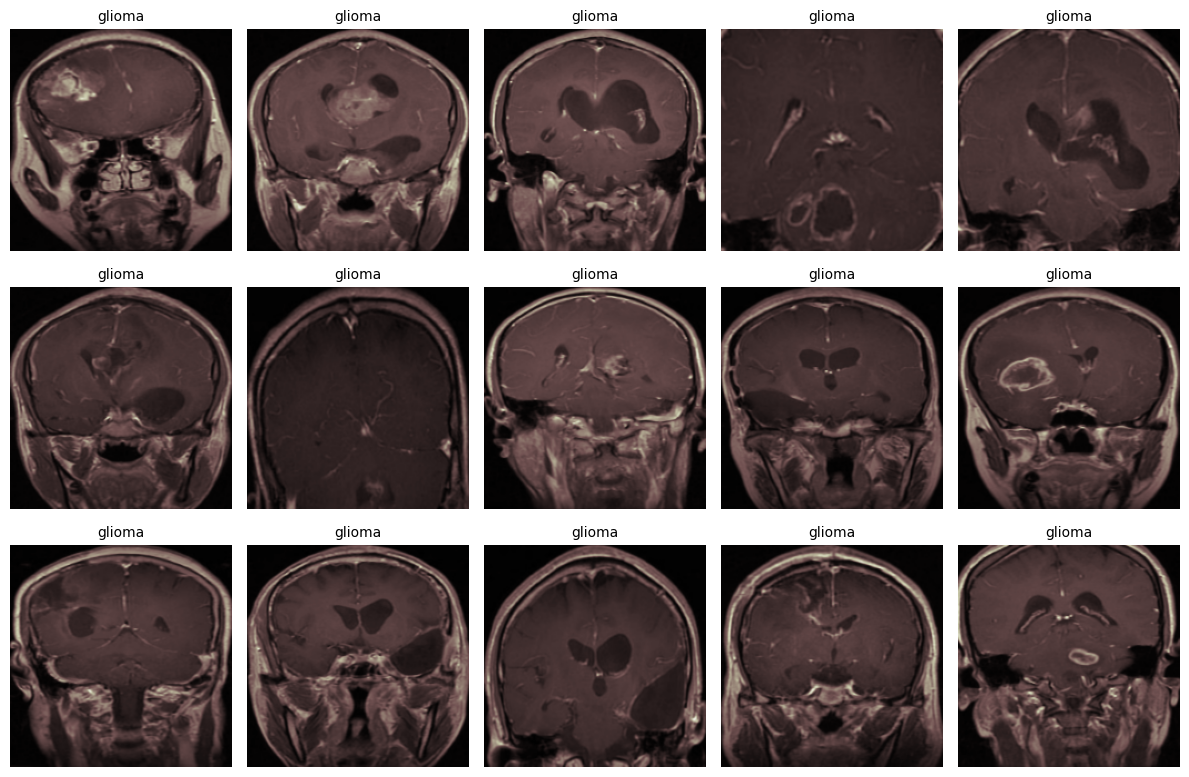

In [7]:
def load_data(data_dir=r'C:\Users\manav\Documents\GitHub\BrainTumorProject\tumorNet_lite\cleaned2', image_size=200):
    """Load and preprocess brain tumor images"""
    
    labels_list = ['glioma', 'meningioma', 'notumor', 'pituitary']
    
    x_train, y_train = [], []
    x_test, y_test = [], []
    
    print("\n" + "="*70)
    print("LOADING DATA")
    print("="*70)
    
    print("\nLoading training data...")
    for label_idx, label in enumerate(labels_list):
        train_path = os.path.join(data_dir, 'Training', label)
        files = os.listdir(train_path)
        for file in tqdm(files, desc=f'{label:12s}'):
            img = cv2.imread(os.path.join(train_path, file), 0)
            img = cv2.bilateralFilter(img, 2, 50, 50)
            img = cv2.applyColorMap(img, cv2.COLORMAP_BONE)
            img = cv2.resize(img, (image_size, image_size))
            x_train.append(img)
            y_train.append(label_idx)
    
    print("\nLoading testing data...")
    for label_idx, label in enumerate(labels_list):
        test_path = os.path.join(data_dir, 'Testing', label)
        files = os.listdir(test_path)
        for file in tqdm(files, desc=f'{label:12s}'):
            img = cv2.imread(os.path.join(test_path, file), 0)
            img = cv2.bilateralFilter(img, 2, 50, 50)
            img = cv2.applyColorMap(img, cv2.COLORMAP_BONE)
            img = cv2.resize(img, (image_size, image_size))
            x_test.append(img)
            y_test.append(label_idx)
    
    x_train = np.array(x_train).astype(np.float32) / 255.0
    x_test = np.array(x_test).astype(np.float32) / 255.0
    y_train = np.array(y_train)
    y_test = np.array(y_test)
    
    print(f"\n{'='*70}")
    print(f"Training data:   {x_train.shape}")
    print(f"Testing data:    {x_test.shape}")
    print(f"{'='*70}")
    
    return x_train, y_train, x_test, y_test, labels_list

# Load data
IMAGE_SIZE = 200
x_train, y_train, x_test, y_test, class_names = load_data(image_size=IMAGE_SIZE)

# Visualize sample images
print("\nVisualizing sample images...")
fig, axes = plt.subplots(3, 5, figsize=(12, 8))
axes = axes.flatten()
for i, ax in enumerate(axes):
    if i < len(x_train):
        ax.imshow(x_train[i])
        ax.set_title(class_names[y_train[i]], fontsize=10)
        ax.axis('off')
plt.tight_layout()
plt.show()

In [8]:
print("\n" + "="*70)
print("PREPARING DATA LOADERS")
print("="*70)

# Train-validation split
x_train, x_val, y_train, y_val = train_test_split(
    x_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print(f"\nTraining samples:   {len(x_train)}")
print(f"Validation samples: {len(x_val)}")
print(f"Test samples:       {len(x_test)}")

# Define transforms
train_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225]),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

# Create datasets
train_dataset = BrainTumorDataset(x_train, y_train, train_transform)
val_dataset = BrainTumorDataset(x_val, y_val, val_transform)
test_dataset = BrainTumorDataset(x_test, y_test, val_transform)

# Create dataloaders
BATCH_SIZE = 32
NUM_WORKERS = 0

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True if torch.cuda.is_available() else False
)

val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True if torch.cuda.is_available() else False
)

test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True if torch.cuda.is_available() else False
)

print(f"\nBatch size: {BATCH_SIZE}")
print(f"Training batches:   {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches:       {len(test_loader)}")
print("="*70)



PREPARING DATA LOADERS

Training samples:   4569
Validation samples: 1143
Test samples:       1311

Batch size: 32
Training batches:   143
Validation batches: 36
Test batches:       41


In [9]:
print("\n" + "="*70)
print("MODEL INITIALIZATION")
print("="*70)

# Create model
NUM_CLASSES = 4
model = TumorNetLite(num_classes=NUM_CLASSES, pretrained=True).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nTotal Parameters:        {total_params:,}")
print(f"Trainable Parameters:    {trainable_params:,}")
print(f"Non-trainable Parameters: {total_params - trainable_params:,}")
print(f"Model Size:              ~{total_params * 4 / (1024**2):.2f} MB")

# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.0001, weight_decay=0.01)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.3, patience=5, verbose=True
)

print("\n✓ Model initialized and moved to", device)
print("="*70)


MODEL INITIALIZATION

Total Parameters:        2,842,748
Trainable Parameters:    2,842,748
Non-trainable Parameters: 0
Model Size:              ~10.84 MB

✓ Model initialized and moved to cuda


In [10]:

from torch.amp import autocast, GradScaler
scaler = GradScaler("cuda")

def train_one_epoch(model, train_loader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    pbar = tqdm(train_loader, desc='Training')
    for inputs, labels in pbar:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        with autocast(device_type=device.type):
            outputs = model(inputs)
            loss = criterion(outputs, labels)
        
        scaler.scale(loss).backward()

        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        pbar.set_postfix({'loss': f'{loss.item():.4f}', 
                         'acc': f'{100.*correct/total:.2f}%'})
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    
    return epoch_loss, epoch_acc


def validate(model, val_loader, criterion, device):
    """Validate the model"""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        pbar = tqdm(val_loader, desc='Validation')
        for inputs, labels in pbar:
            inputs, labels = inputs.to(device), labels.to(device)
            
            with autocast(device_type=device.type):    
                outputs = model(inputs)
                loss = criterion(outputs, labels)
            
            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            pbar.set_postfix({'loss': f'{loss.item():.4f}', 
                             'acc': f'{100.*correct/total:.2f}%'})
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    
    return epoch_loss, epoch_acc

print("✓ Training functions defined")


✓ Training functions defined


In [11]:
print("\n" + "="*70)
print("STARTING TRAINING")
print("="*70)

NUM_EPOCHS = 100
PATIENCE = 7

best_val_acc = 0.0
patience_counter = 0
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': []
}

start_time = time.time()

for epoch in range(NUM_EPOCHS):
    print(f'\nEpoch {epoch+1}/{NUM_EPOCHS}')
    print('-' * 70)
    
    # Train
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    
    # Validate
    val_loss, val_acc = validate(model, val_loader, criterion, device)
    
    # Update history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    # Print epoch summary
    print(f'\nEpoch {epoch+1} Summary:')
    print(f'  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} ({train_acc*100:.2f}%)')
    print(f'  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f} ({val_acc*100:.2f}%)')
    
    # Learning rate scheduling
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    print(f'  Learning Rate: {current_lr:.6f}')
    
    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'val_loss': val_loss,
        }, 'tumornet_lite_best2.pth')
        print(f'  ✓ Best model saved! Val Acc: {val_acc:.4f}')
        patience_counter = 0
    else:
        patience_counter += 1
        print(f'  Patience: {patience_counter}/{PATIENCE}')
    
    # Early stopping
    if patience_counter >= PATIENCE:
        print(f'\n⚠ Early stopping triggered after {epoch+1} epochs')
        break

training_time = time.time() - start_time
print("\n" + "="*70)
print("TRAINING COMPLETED!")
print("="*70)
print(f"Total training time: {training_time/60:.2f} minutes")
print(f"Best validation accuracy: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")
print("="*70)



STARTING TRAINING

Epoch 1/100
----------------------------------------------------------------------


Validation: 100%|██████████| 36/36 [00:08<00:00,  4.22it/s, loss=1.2163, acc=59.06%]



Epoch 1 Summary:
  Train Loss: 1.1457 | Train Acc: 0.5178 (51.78%)
  Val Loss:   1.0114 | Val Acc:   0.5906 (59.06%)
  Learning Rate: 0.000100
  ✓ Best model saved! Val Acc: 0.5906

Epoch 2/100
----------------------------------------------------------------------


Validation: 100%|██████████| 36/36 [00:08<00:00,  4.38it/s, loss=1.0066, acc=65.00%]



Epoch 2 Summary:
  Train Loss: 0.9706 | Train Acc: 0.6060 (60.60%)
  Val Loss:   0.8672 | Val Acc:   0.6500 (65.00%)
  Learning Rate: 0.000100
  ✓ Best model saved! Val Acc: 0.6500

Epoch 3/100
----------------------------------------------------------------------


...


Epoch 65 Summary:
  Train Loss: 0.0533 | Train Acc: 0.9836 (98.36%)
  Val Loss:   0.1058 | Val Acc:   0.9738 (97.38%)
  Learning Rate: 0.000100
  Patience: 5/7

Epoch 66/100
----------------------------------------------------------------------


Validation: 100%|██████████| 36/36 [00:08<00:00,  4.39it/s, loss=0.0653, acc=97.11%]



Epoch 66 Summary:
  Train Loss: 0.0531 | Train Acc: 0.9827 (98.27%)
  Val Loss:   0.1047 | Val Acc:   0.9711 (97.11%)
  Learning Rate: 0.000030
  Patience: 6/7

Epoch 67/100
----------------------------------------------------------------------


Validation: 100%|██████████| 36/36 [00:08<00:00,  4.40it/s, loss=0.1468, acc=97.46%]


Epoch 67 Summary:
  Train Loss: 0.0309 | Train Acc: 0.9902 (99.02%)
  Val Loss:   0.0991 | Val Acc:   0.9746 (97.46%)
  Learning Rate: 0.000030
  Patience: 7/7

⚠ Early stopping triggered after 67 epochs

TRAINING COMPLETED!
Total training time: 126.01 minutes
Best validation accuracy: 0.9764 (97.64%)



VISUALIZING TRAINING HISTORY


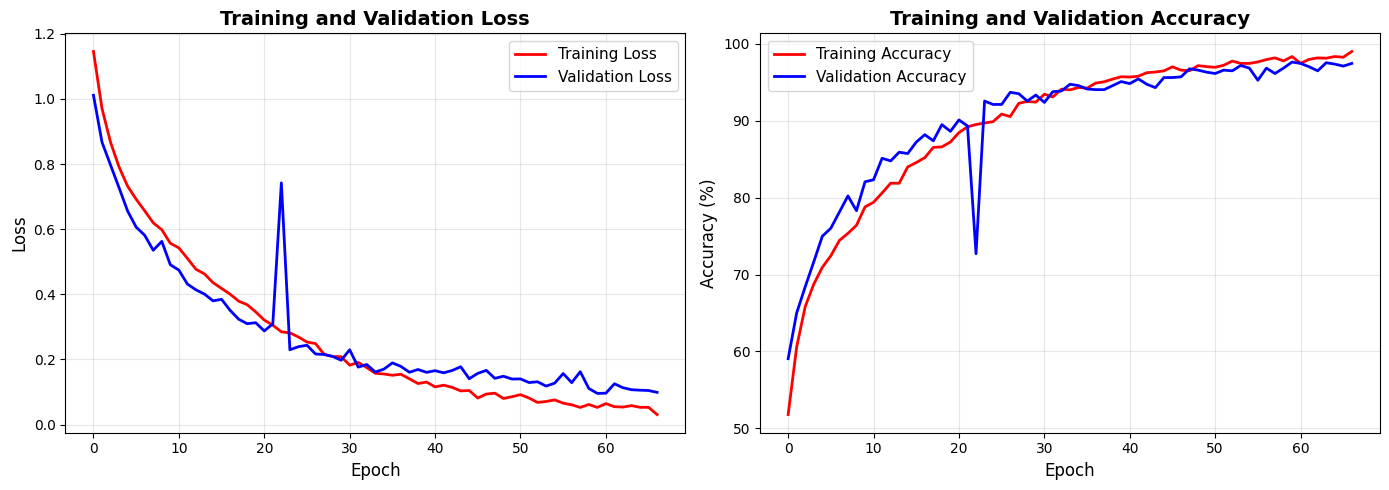

In [12]:
print("\n" + "="*70)
print("VISUALIZING TRAINING HISTORY")
print("="*70)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
axes[0].plot(history['train_loss'], 'r-', linewidth=2, label='Training Loss')
axes[0].plot(history['val_loss'], 'b-', linewidth=2, label='Validation Loss')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training and Validation Loss', fontsize=14, weight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)

# Accuracy plot
axes[1].plot([x*100 for x in history['train_acc']], 'r-', linewidth=2, label='Training Accuracy')
axes[1].plot([x*100 for x in history['val_acc']], 'b-', linewidth=2, label='Validation Accuracy')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1].set_title('Training and Validation Accuracy', fontsize=14, weight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_history2.png', dpi=300, bbox_inches='tight')
plt.show()


In [13]:
print("\n" + "="*70)
print("LOADING BEST MODEL FOR EVALUATION")
print("="*70)

# Load best model
checkpoint = torch.load('tumornet_lite_best2.pth')
model.load_state_dict(checkpoint['model_state_dict'])
print(f"✓ Loaded best model from epoch {checkpoint['epoch']+1}")
print(f"  Validation accuracy: {checkpoint['val_acc']:.4f}")

# Evaluate on test set
model.eval()
all_preds = []
all_labels = []
all_probs = []

print("\nEvaluating on test set...")
with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc='Testing'):
        inputs = inputs.to(device)
        outputs = model(inputs)
        probs = F.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

# Calculate metrics
test_acc = np.mean(np.array(all_preds) == np.array(all_labels))

print("\n" + "="*70)
print("TEST SET RESULTS")
print("="*70)
print(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
print("="*70)



LOADING BEST MODEL FOR EVALUATION
✓ Loaded best model from epoch 60
  Validation accuracy: 0.9764

Evaluating on test set...


Testing: 100%|██████████| 41/41 [00:06<00:00,  6.75it/s]


TEST SET RESULTS
Test Accuracy: 0.9748 (97.48%)



CONFUSION MATRIX


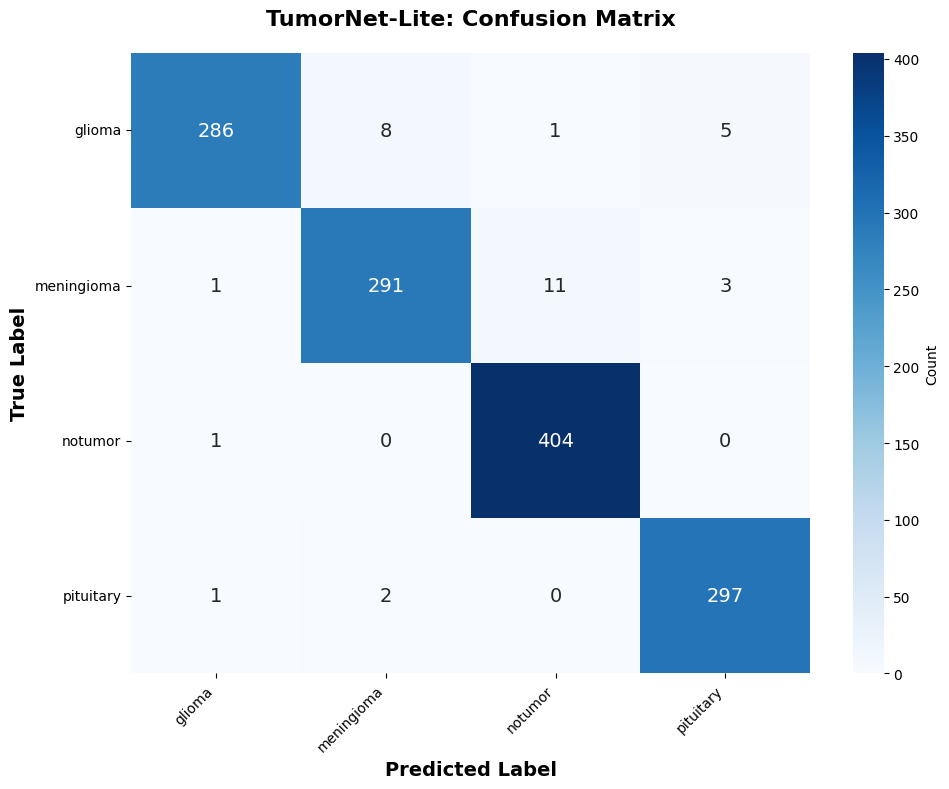


Normalized Confusion Matrix:
            glioma  meningioma  notumor  pituitary
glioma      0.9533      0.0267   0.0033     0.0167
meningioma  0.0033      0.9510   0.0359     0.0098
notumor     0.0025      0.0000   0.9975     0.0000
pituitary   0.0033      0.0067   0.0000     0.9900


In [14]:
print("\n" + "="*70)
print("CONFUSION MATRIX")
print("="*70)

# Compute confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Plot
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'}, annot_kws={'size': 14})
plt.title('TumorNet-Lite: Confusion Matrix', fontsize=16, weight='bold', pad=20)
plt.ylabel('True Label', fontsize=14, weight='bold')
plt.xlabel('Predicted Label', fontsize=14, weight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix2.png', dpi=300, bbox_inches='tight')
plt.show()

# Print normalized confusion matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
print("\nNormalized Confusion Matrix:")
print(pd.DataFrame(cm_normalized, index=class_names, columns=class_names).round(4))


In [15]:
print("\n" + "="*70)
print("DETAILED CLASSIFICATION REPORT")
print("="*70)

print(classification_report(all_labels, all_preds, 
                           target_names=class_names, digits=4))

# Per-class metrics
precision, recall, f1, support = precision_recall_fscore_support(
    all_labels, all_preds
)

print("\nPer-Class Metrics Summary:")
print("-" * 70)
print(f"{'Class':<15} {'Precision':<12} {'Recall':<12} {'F1-Score':<12} {'Support':<10}")
print("-" * 70)
for i, name in enumerate(class_names):
    print(f"{name:<15} {precision[i]:<12.4f} {recall[i]:<12.4f} {f1[i]:<12.4f} {support[i]:<10}")
print("-" * 70)
print(f"{'Average':<15} {np.mean(precision):<12.4f} {np.mean(recall):<12.4f} {np.mean(f1):<12.4f} {np.sum(support):<10}")
print("="*70)



DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

      glioma     0.9896    0.9533    0.9711       300
  meningioma     0.9668    0.9510    0.9588       306
     notumor     0.9712    0.9975    0.9842       405
   pituitary     0.9738    0.9900    0.9818       300

    accuracy                         0.9748      1311
   macro avg     0.9753    0.9730    0.9740      1311
weighted avg     0.9750    0.9748    0.9747      1311


Per-Class Metrics Summary:
----------------------------------------------------------------------
Class           Precision    Recall       F1-Score     Support   
----------------------------------------------------------------------
glioma          0.9896       0.9533       0.9711       300       
meningioma      0.9668       0.9510       0.9588       306       
notumor         0.9712       0.9975       0.9842       405       
pituitary       0.9738       0.9900       0.9818       300       
---------------------------------


PER-CLASS PERFORMANCE VISUALIZATION


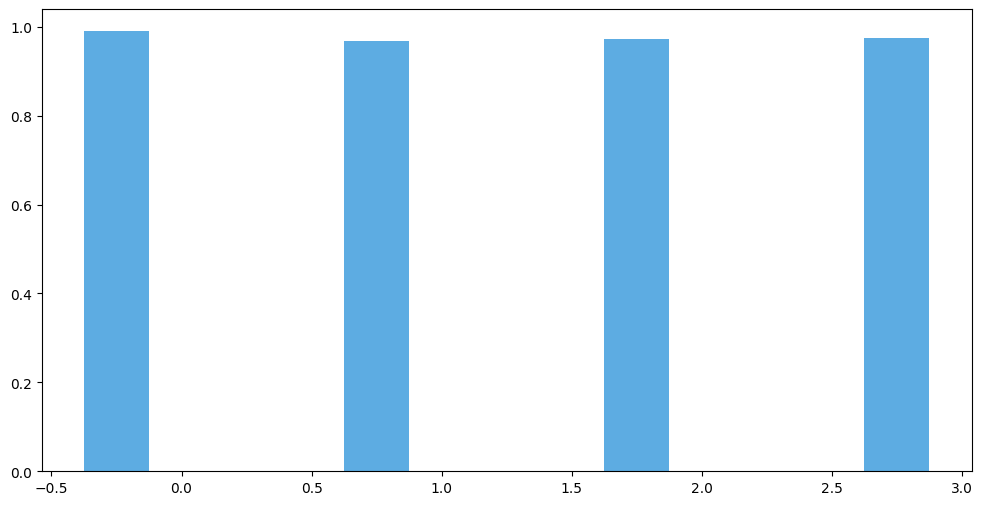

In [16]:
print("\n" + "="*70)
print("PER-CLASS PERFORMANCE VISUALIZATION")
print("="*70)

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(class_names))
width = 0.25

bars1 = ax.bar(x - width, precision, width, label='Precision', 
              color='#3498db', alpha=0.8)